## 1. Data Preprocessing & Feature Engineering

In [1]:
import numpy as np
import pandas as pd

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

print(f"X: {X.shape}\n", X)
print(100*'=')
print(f"y: {y.shape}\n", y)

X: (10000, 10)
 [[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]
y: (10000,)
 [1 0 1 ... 1 1 0]


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

print(f"X: {X.shape}\n", X)

X: (10000, 10)
 [[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

print(f"X: {X.shape}\n", X)

X: (10000, 12)
 [[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Building the Multi-Layer Perceptron (MLP)

In [8]:
class MLP:
    def __init__(self, LR, X_train, y_train, X_test, y_test, hidden_dim=8):
        input_dim = X_train.shape[1]

        self.w1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.random.randn(hidden_dim)
        
        self.w2 = np.random.randn(hidden_dim) * 0.1
        self.b2 = 0.0

        self.LR = LR
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.L_train = []
        self.L_test = []

    def sigmoid(self, x):
        # sigmoid
        x = np.clip(x, -500, 500) 
        return 1 / (1 + np.exp(-x))
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def forward(self, X, return_cache=False):
        hidden_1 = np.dot(X, self.w1) + self.b1
        activate_1 = self.relu(hidden_1)
        
        hidden_2 = np.dot(activate_1, self.w2) + self.b2
        activate_2 = self.sigmoid(hidden_2)
        
        if return_cache:
            return activate_2, activate_1, hidden_1
        return activate_2

    def backward(self, X_batch, y_true_batch, y_pred_batch, a1_batch, h1_batch):
        batch_size = X_batch.shape[0]
        
        dL_dhidden2 = (y_pred_batch - y_true_batch) / batch_size
        
        dL_dw2 = np.dot(a1_batch.T, dL_dhidden2)
        dL_db2 = np.sum(dL_dhidden2, axis=0) 

        dL_dhidden2_reshaped = dL_dhidden2.reshape(-1, 1)
        
        dL_dhidden1 = np.dot(dL_dhidden2_reshaped, self.w2.reshape(1, -1)) * self.relu_derivative(h1_batch)
        
        dL_dw1 = np.dot(X_batch.T, dL_dhidden1)
        dL_db1 = np.sum(dL_dhidden1, axis=0)
        
        return dL_db1, dL_dw1, dL_db2, dL_dw2
    
    def optimizer(self, dL_db1, dL_dw1, dL_db2, dL_dw2):
        self.w1 -= dL_dw1 * self.LR
        self.b1 -= dL_db1 * self.LR
        self.w2 -= dL_dw2 * self.LR
        self.b2 -= dL_db2 * self.LR

    def train(self, n_iter, batch_size=32):
        for i in range(n_iter):
            # Mini-Batch
            indices = np.random.choice(len(self.X_train), size=batch_size, replace=False)
            X_batch = self.X_train[indices]
            y_true_batch = self.y_train[indices]
            
            y_pred_batch, a1_batch, h1_batch = self.forward(X_batch, return_cache=True)
            
            pred_clipped = np.clip(y_pred_batch, 1e-15, 1 - 1e-15)
            L = -np.mean(y_true_batch * np.log(pred_clipped) + (1 - y_true_batch) * np.log(1 - pred_clipped))
            self.L_train.append(L)
            
            dL_db1, dL_dw1, dL_db2, dL_dw2 = self.backward(X_batch, y_true_batch, y_pred_batch, a1_batch, h1_batch)
            self.optimizer(dL_db1, dL_dw1, dL_db2, dL_dw2)
            
        self.evaluate_test()
        return "done."
    
    def evaluate_test(self):
        y_pred = self.forward(self.X_test)
        pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
        L = -np.mean(self.y_test * np.log(pred_clipped) + (1 - self.y_test) * np.log(1 - pred_clipped))
        self.L_test.append(L)

## 3. Model Hyperparameters & Training Execution

In [9]:
LR = 0.05
n_iter = 5000

In [10]:
mlp = MLP(LR=LR, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
mlp.train(n_iter=n_iter, batch_size=32)

'done.'

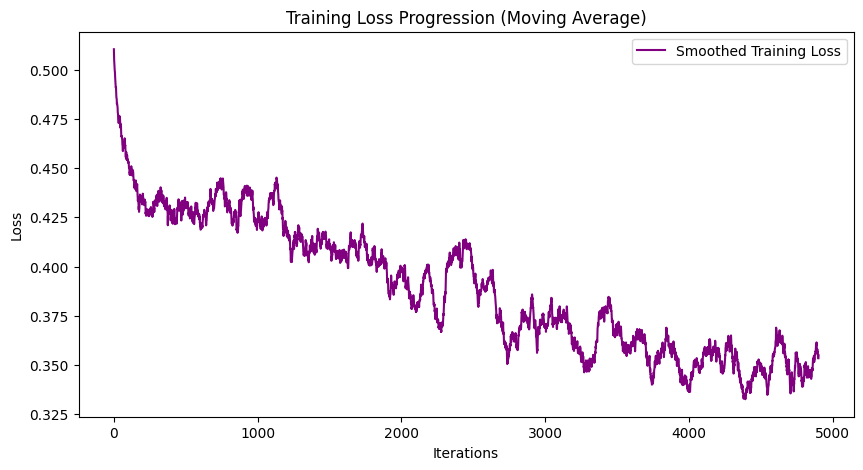

In [11]:
import matplotlib.pyplot as plt
window_size = 100
smoothed_loss = np.convolve(mlp.L_train, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smoothed_loss, color='purple', label='Smoothed Training Loss')
plt.title('Training Loss Progression (Moving Average)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Model Evaluation, Performance Metrics & Decision Threshold Optimization

In [12]:
y_preds = np.round(mlp.forward(X_test))

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score
print("--- Evaluation Results ---")
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_preds)
print(f"Accuracy Score: {acc * 100:.2f}%")

--- Evaluation Results ---
Confusion Matrix:
 [[1573   34]
 [ 251  142]]
Accuracy Score: 85.75%


Best Threshold: 0.28
Max F1-Score at: 0.60


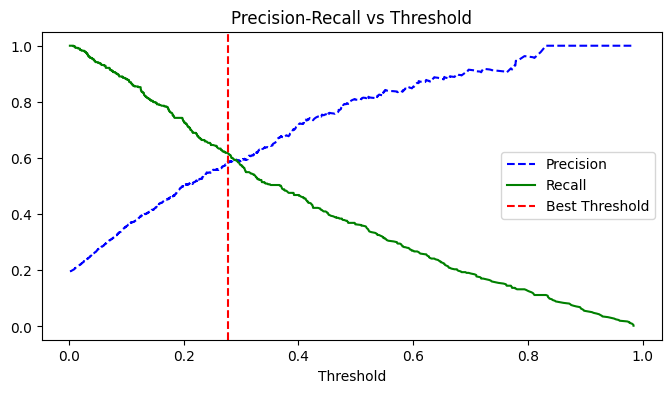

In [14]:
from sklearn.metrics import precision_recall_curve

y_probs = mlp.forward(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-15)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Max F1-Score at: {f1_scores[best_idx]:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.title("Precision-Recall vs Threshold")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [15]:
y_preds = (y_probs >= best_threshold).astype(int)

print(f"--- Evaluation Results (Threshold = {best_threshold:.2f}) ---")
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_preds)
print(f"Accuracy Score: {acc * 100:.2f}%")

--- Evaluation Results (Threshold = 0.28) ---
Confusion Matrix:
 [[1435  172]
 [ 150  243]]
Accuracy Score: 83.90%
